### Dataset Info ###
Antal rader: 12000
Antal kolumner: 18

Datatyper:
int64      11
str         4
float64     3
Name: count, dtype: int64

Saknade värden per kolumn:
region                        340
price                         818
time_to_first_response_min    590
dtype: int64


C:\Users\tobia\AppData\Local\Temp\ipykernel_31364\1409780121.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns


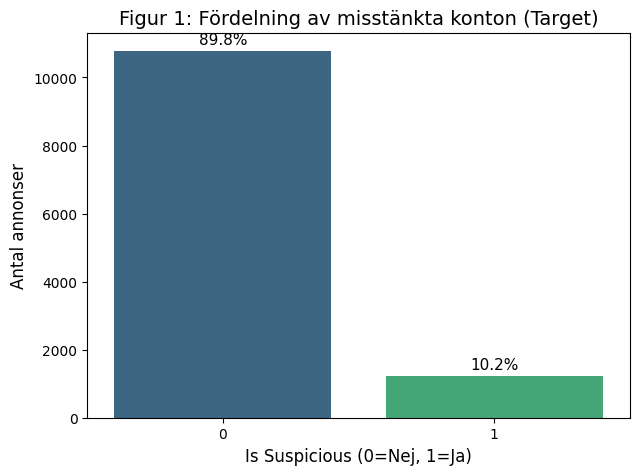

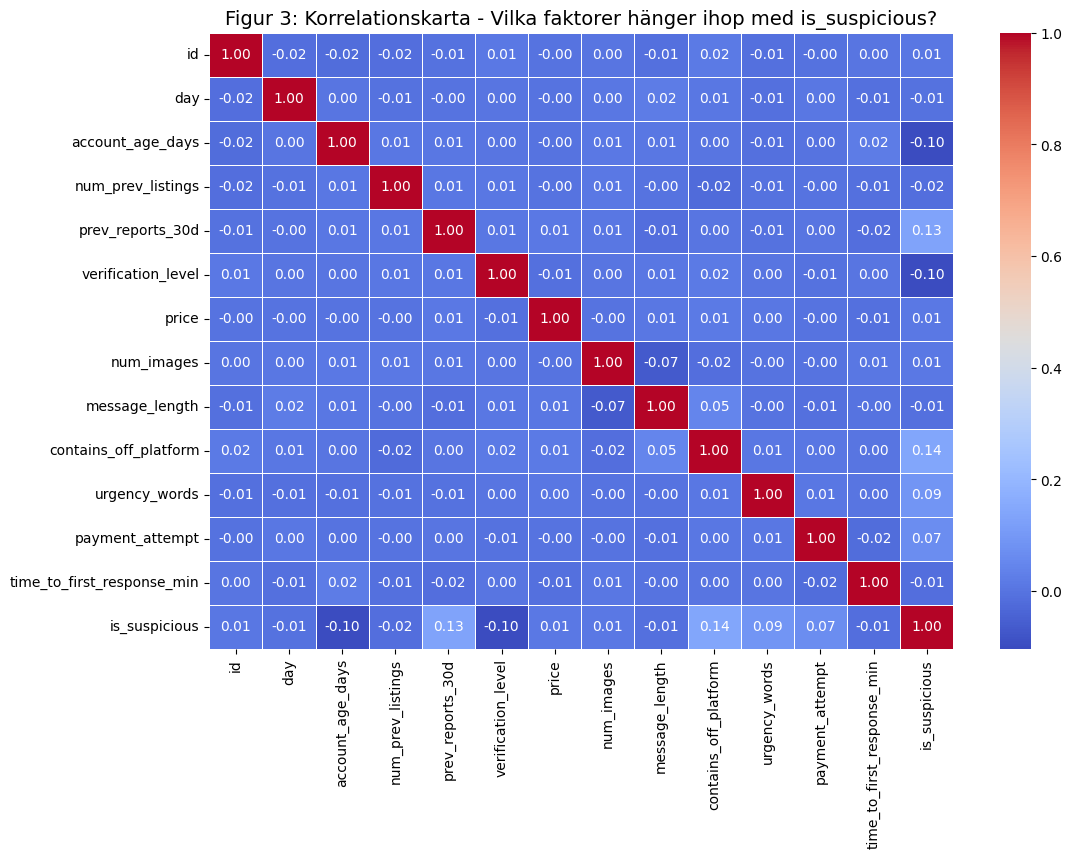

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('historical_data.csv')

print("### Dataset Info ###")
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print("\nDatatyper:")
print(df.dtypes.value_counts())


missing_values = df.isnull().sum()
print("\nSaknade värden per kolumn:")
print(missing_values[missing_values > 0])


numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
 



plt.figure(figsize=(7, 5))
ax = sns.countplot(x='is_suspicious', data=df, palette='viridis', hue='is_suspicious', legend=False)
plt.title('Figur 1: Fördelning av misstänkta konton (Target)', fontsize=14)
plt.xlabel('Is Suspicious (0=Nej, 1=Ja)', fontsize=12)
plt.ylabel('Antal annonser', fontsize=12)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()


plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Figur 3: Korrelationskarta - Vilka faktorer hänger ihop med is_suspicious?', fontsize=14)
plt.show()

Man kan se tecken till starkare kopplingar med is_suspicious och kategorierna contains_off_platform (0.14), prev_reports_30d(0.13) samt urgency_words(0.09). Medan vi kan se ingen koppling eller extremt svag koppling i kategorier som account_age_days(-0.10) och verification_level (-0.10). Vilket kan tyda på att ju äldre och mer verfikation det är på kontot ju mindre koppling kan vi se.